<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">


# Clustering and K-Means Lab


---


### Lab Objectives
* Penguin dataset is used mainly for classification as we have labels, however, we will assume we do not have a label and we would use the dataset for clustering 


In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

#### Describing the data

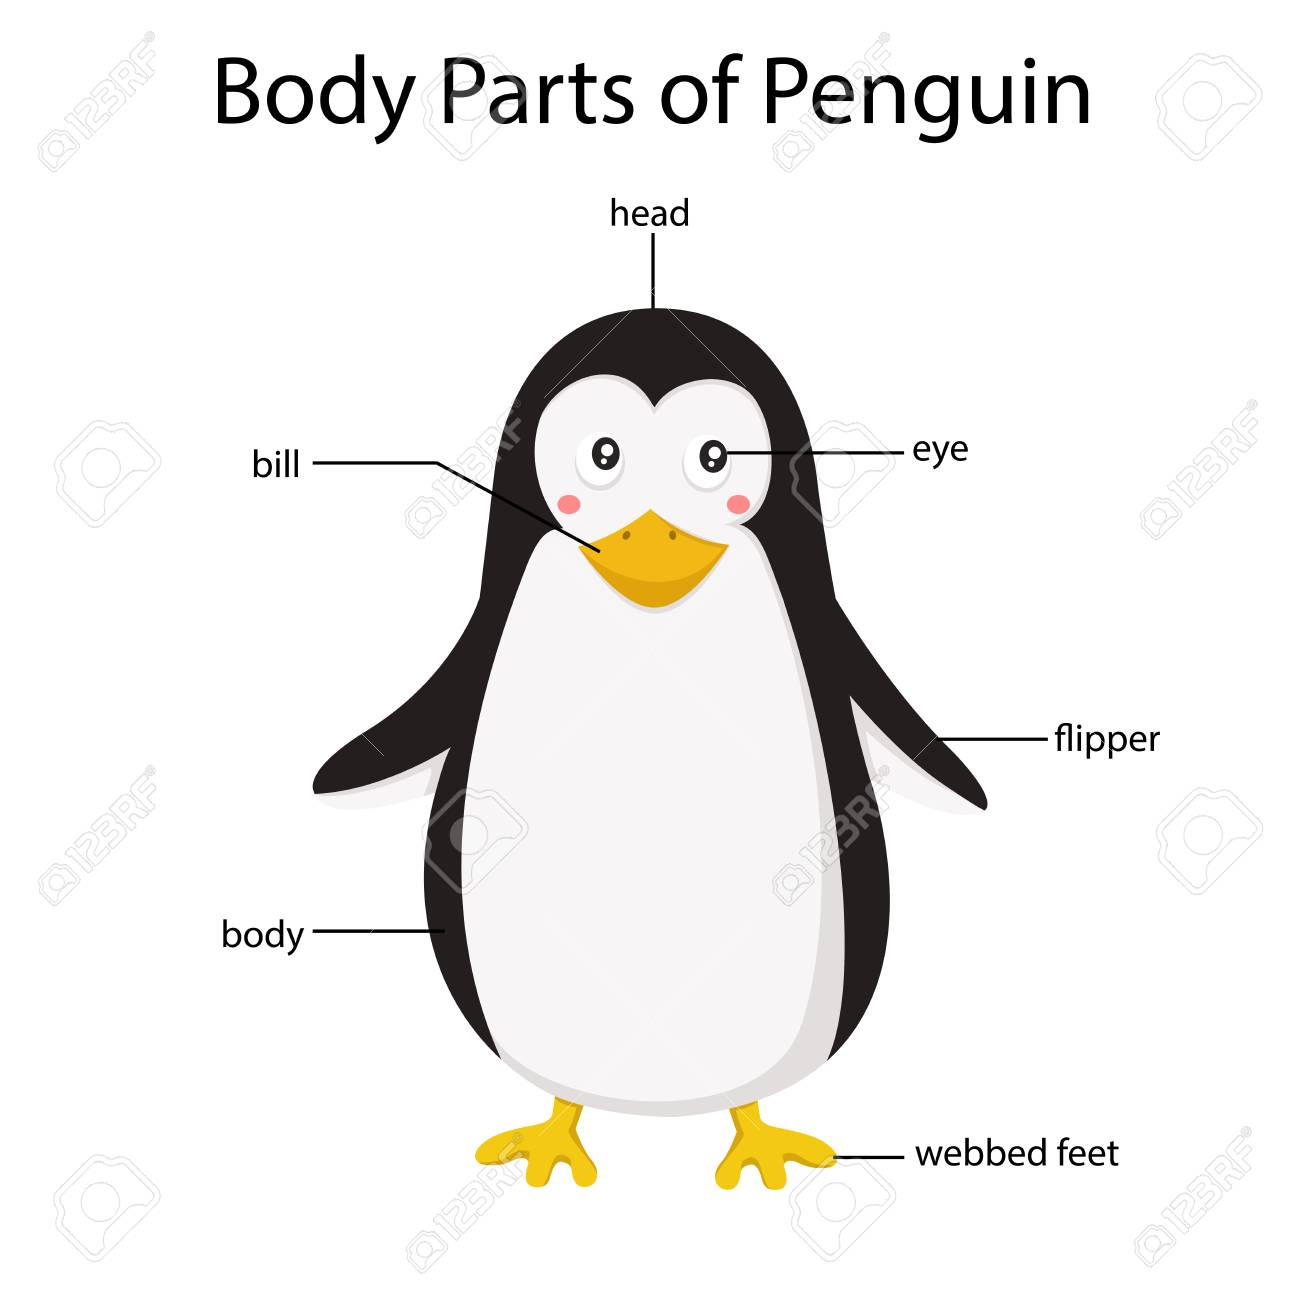

**Columns in the dataset** 
- Species: penguin species (Chinstrap, Adélie, or Gentoo)
- Island: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)
- flipper_length_mm: flipper length (mm)
- body_mass_g: body mass (g)
- Sex: penguin sex



In [3]:
# load the dataset from seaborn using sns.load_dataset. It is called penguins
penguins = sns.load_dataset('penguins')

# show the head
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
# check columns info
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [5]:
# do we have any nulls?
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [6]:
# Drop null values from the dataset
penguins = penguins.dropna().reset_index(drop=True)

# check the shape after dropping
penguins.shape

(333, 7)

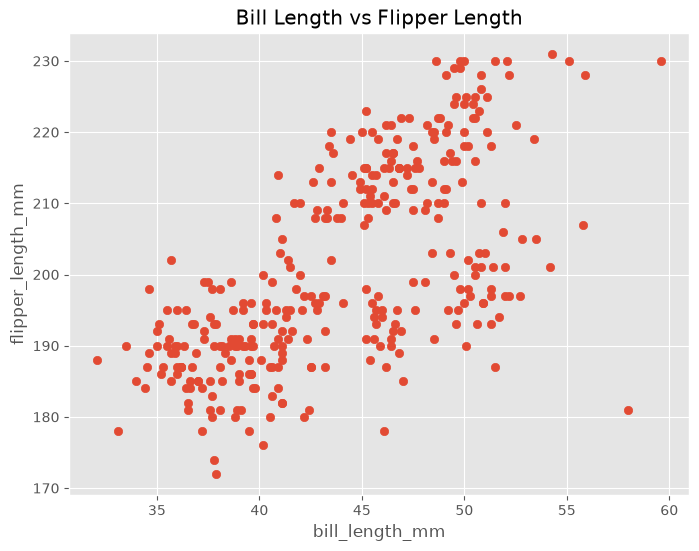

In [11]:
# make scatter between bill length and flipper length
plt.figure(figsize=(8, 6))
plt.scatter(penguins['bill_length_mm'], penguins['flipper_length_mm'])
plt.xlabel('bill_length_mm')
plt.ylabel('flipper_length_mm')
plt.title('Bill Length vs Flipper Length')
plt.show()

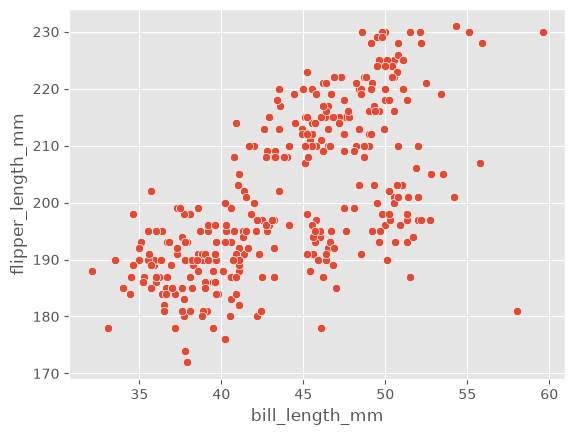

In [7]:
# No code here



In [12]:
# set our X features to be bill length and flipper length
X = penguins[['bill_length_mm', 'flipper_length_mm']]

In [13]:
# Important step: scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# instantiate kmeans model with 8 cluster, random state 7
model1 = KMeans(n_clusters=8, random_state=7)
model1.fit(X_scaled)

,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",7
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](8, 2)","[[

In [15]:
# get centroids of model1
# inverse the scaling of cluster_centers_ and save it into a variable centers
centers = scaler.inverse_transform(model1.cluster_centers_)

# create a dataframe called cluster1 contains the centers, define the column names as x1 and y1
cluster1 = pd.DataFrame(centers, columns=['x1', 'y1'])
cluster1

,x1,y1
0,39.302703,182.594595
1,46.322414,214.086207
2,36.991781,190.575342
3,50.959524,198.428571
4,43.692157,192.549020
5,49.780488,222.097561
6,54.385714,229.571429
7,42.416667,207.083333


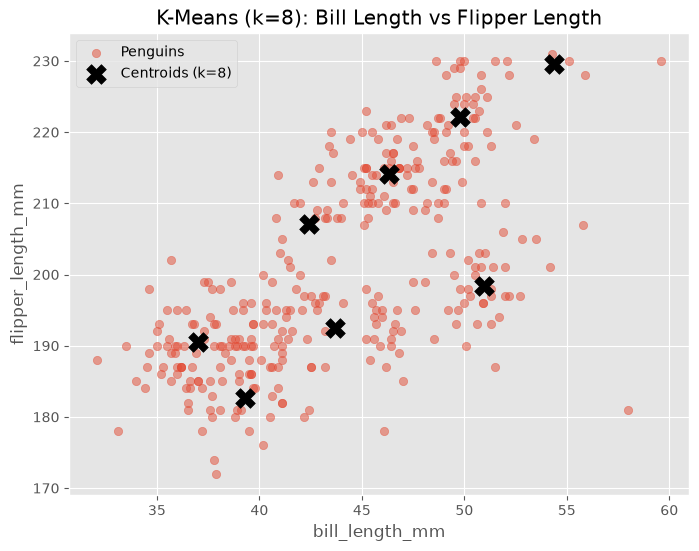

In [20]:
# create two scatter plots:
# first:  from penguins main dataframe,plotting bill length against flipper length
# second: from clusters dataframe that you have created in previous code cell
plt.figure(figsize=(8, 6))
plt.scatter(penguins['bill_length_mm'], penguins['flipper_length_mm'], alpha=0.5, label='Penguins')
plt.scatter(cluster1['x1'], cluster1['y1'], color='black', marker='X', s=200, label='Centroids (k=8)')
plt.xlabel('bill_length_mm')
plt.ylabel('flipper_length_mm')
plt.title('K-Means (k=8): Bill Length vs Flipper Length')
plt.legend()
plt.show()

In [17]:
# instantiate kmeans model with 3 cluster, random state 7
model2 = KMeans(n_clusters=3, random_state=7)

# fit the model
model2.fit(X_scaled)

# what are the models cluster centers?
model2.cluster_centers_

array([[-0.96427851, -0.80518575],
       [ 0.66403058,  1.15087842],
       [ 0.9235766 , -0.37501448]])

In [18]:
# get centroids of model2
# inverse the scaling of cluster_centers_ and save it into a variable centers2
centers2 = scaler.inverse_transform(model2.cluster_centers_)

# create a dataframe called cluster2 contains the centers2,
# define the column names as x1 and y1
cluster2 = pd.DataFrame(centers2, columns=['x1', 'y1'])
cluster2

,x1,y1
0,38.727397,189.698630
1,47.618699,217.073171
2,49.035938,195.718750


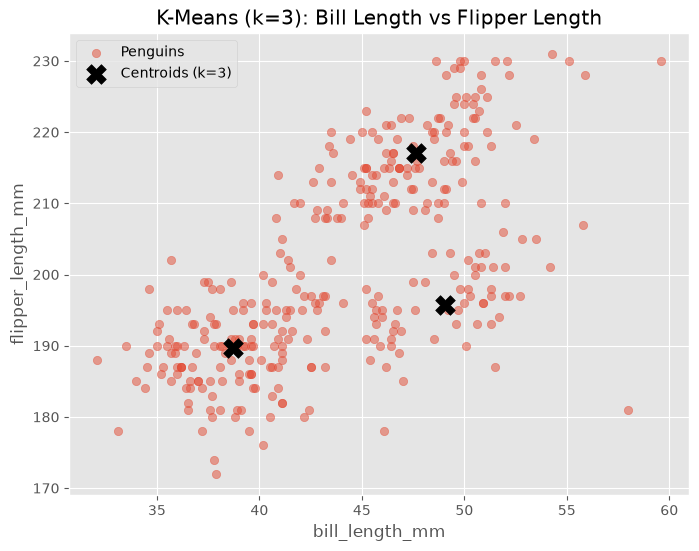

In [21]:
# create two scatter plots:
# first:  from penguins main dataframe,plotting bill length against flipper length
# second: from clusters dataframe that you have created in previous code cell
plt.figure(figsize=(8, 6))
plt.scatter(penguins['bill_length_mm'], penguins['flipper_length_mm'], alpha=0.5, label='Penguins')
plt.scatter(cluster2['x1'], cluster2['y1'], color='black', marker='X', s=200, label='Centroids (k=3)')
plt.xlabel('bill_length_mm')
plt.ylabel('flipper_length_mm')
plt.title('K-Means (k=3): Bill Length vs Flipper Length')
plt.legend()
plt.show()

In [22]:
# create a column cluster_labels in penguins dataframe that has the predictions
penguins['cluster_labels'] = model2.predict(X_scaled)

# display the penguins dataframe with the species and cluster_labels columns
penguins[['species', 'cluster_labels']]

,species,cluster_labels
0,Adelie,0
1,Adelie,0
2,Adelie,0
3,Adelie,0
4,Adelie,0
...,...,...
328,Gentoo,1
329,Gentoo,1
330,Gentoo,1
331,Gentoo,1


> Let's see if the model matches the correct cluster groups or not

In [23]:
# make a crosstab in penguins dataframe between species and cluster_labels
pd.crosstab(penguins['species'], penguins['cluster_labels'])

cluster_labels,0,1,2
species,,,
Adelie,141,1,4
Chinstrap,5,4,59
Gentoo,0,118,1
